# Star 1: shape functions against closed-form theory

**Dataset.** DIC Challenge 2.0, Star 1 (Reu et al., 2022): a noise-free ±0.5 px sinusoidal displacement
whose period grows linearly from 10 to 150 px across the image.

**Theory.** For noise-free images, local DIC converges to the least-squares projection of the true field
onto the shape-function basis (Reu et al. 2022, Appendix), which across a subset is a Savitzky–Golay filter:

- **affine** (order 1): the Dirichlet kernel, sin(πh/λ) / (h·sin(π/λ)); for h = 17 it crosses 0.9 at
  67.8 px, the paper's published value
- **quadratic** (order 2): the order-2 Savitzky–Golay response, computed numerically

**What this establishes for Chapter 5:** a direct test of both shape-function implementations
(the 12-parameter quadratic composition in particular) against a closed-form prediction.

**Expected behaviour.** The curves are jagged around the prediction (pattern-induced bias, the paper's Figs. 3
and 6), and small quadratic subsets fall short of theory: every quadratic code in the Challenge plateaus near 20–25 px at
small length parameters (the paper's Fig. 8). **Star 1's period stops at 150 px**, so affine subsets above
~37 px never regain 90 % inside the image; Stars 5 and 6 cover the longer periods.

> **Results assume a fresh kernel** (*Restart Kernel → Run All*). Python imports each module once per
> kernel, so re-running cells after editing a file in `validation/` keeps the old code. All correlation
> runs are cached, so a full re-run is quick.

In [2]:
import os
import sys
from pathlib import Path

# The notebook lives in validation/notebooks/; the validation package lives at the repository root.
REPO = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

# Environment variables win, so another machine or a CI job runs the notebook unchanged.
CHALLENGE2 = Path(os.environ.get("DIC_CHALLENGE2", "~/Documents/dicsamples/2D-Challenge2")).expanduser()
RESULTS = Path(os.environ.get("DIC_RESULTS", "~/Documents/dicresults-clean")).expanduser()

# True re-runs every configuration even when its output already exists.
FORCE = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from validation.runner import Dataset, SweepPoint, expand_grid, score_run
from validation.workflow import run_point, write_base_config
from validation.resolution import attenuation_theory, code_mei, theoretical_resolution
from validation.star import (STAR_SETS, STRAIN_GRADIENT, STRAIN_GREEN_LAGRANGE, analyse_line_cut,
                             band_height, centre_row, image_shape, plateau, write_band_roi)
from validation.truth import NoTruth
from validation.workflow import row_cut, run_quality

print("repo    :", REPO)
print("data    :", CHALLENGE2)
print("results :", RESULTS)

In [3]:
def star_dataset(star, name: str, frames: list[str]):
    """Base config for one Star set; subset, ROI band and search window are set per run."""
    base = {
        "session": {
            "image_dir": str(CHALLENGE2 / star.folder),
            "mode": "explicit",
            "reference_frame": star.reference,
            "explicit_frame_list": "frames.txt",
        },
        "setup": {"subset_size": 17, "step_size": 1},
        "correlation": {
            "search_size": 27,
            "correlation_mode": "spatial",
            "tracking_mode": "eulerian",
            "criterion_name": "znssd",
            "match_threshold": 0.6,
            "n_workers": 4,
            "search": {"method": "brute"},
            "refinement": {"method": "icgn", "shape_function": "affine"},
            "strain": {"method": "lagrange_q4", "strain_window": 5},
            "image_interpolation": {"method": "biquintic_spline"},
        },
    }
    config_path, runs_root = write_base_config(base, name, RESULTS)
    (config_path.parent / "frames.txt").write_text("\n".join(frames) + "\n")
    return Dataset(name, config_path, NoTruth("resolution study")), runs_root


def star_point(subset: int, shape: str, roi: Path, strain_window: int | None = None) -> SweepPoint:
    overrides = {
        "setup.subset_size": subset,
        "setup.step_size": 1,
        "setup.roi_mask": str(roi),
        # Shifts are below 0.5 px on the rows kept; the window only needs to exceed the subset.
        "correlation.search_size": subset + 10,
        "correlation.refinement.shape_function": shape,
    }
    if strain_window is not None:
        overrides["correlation.strain.method"] = "lagrange_q4"
        overrides["correlation.strain.strain_window"] = strain_window
    return SweepPoint(overrides)


## Geometry: one row of nodes at 1 px spacing

The Challenge protocol reports the centre row at 1 px spacing. The engine uses one isotropic step, so
step 1 over a 501×2000 image would be one million nodes per run. Instead each run gets a **horizontal ROI
band exactly one subset tall**, centred on the middle row. The engine erodes the ROI by the subset
half-width before placing nodes, leaving a single row: the centre row, at 1 px spacing. For strain, the
band is taller by the strain window so the centre row keeps a full window above and below it.

**No Eulerian→Lagrangian correction.** The Challenge 2.0 images come from a closed-form Boolean speckle
model with the true field defined at reference positions (their Eq. 2), which is what DIC reports.

In [4]:
STAR = STAR_SETS["Star1"]
H, W = image_shape(CHALLENGE2 / STAR.folder / STAR.reference)
ROW = centre_row(H)
print(f"{STAR.folder}: {H}x{W}, centre row {ROW}, "
      f"period {STAR.period(0):.2f} -> {STAR.period(W - 1):.2f} px")

SUBSETS = [9, 13, 17, 25, 33]
SHAPES = ["affine", "quadratic"]
ORDER = {"affine": 1, "quadratic": 2}

dataset, runs_root = star_dataset(STAR, "star1", [STAR.deformed])


Star1NoNoise: 501x2000, centre row 250, period 10.07 -> 150.00 px


In [5]:
cuts, rows = [], []
for subset in SUBSETS:
    roi = write_band_roi(runs_root.parent / "roi" / f"band_{subset}.tiff", (H, W), band_height(subset))
    for shape in SHAPES:
        outcome = run_point(dataset, runs_root, star_point(subset, shape, roi), repo=REPO, force=FORCE)
        if not outcome.ok:
            continue
        x0, v = row_cut(outcome.output_dir, STAR.deformed, "v_px", ROW)
        m = analyse_line_cut(STAR, x0, v)
        cuts.append(pd.DataFrame({"subset": subset, "shape": shape,
                                  "period": STAR.period(x0), "ratio": m["sign"] * v / STAR.amplitude}))
        rows.append({"subset": subset, "shape": shape, "sign": m["sign"],
                     "l10_measured": m["l10_px"],
                     "l10_conservative": m["l10_conservative_px"],
                     "l10_theory": theoretical_resolution(subset, ORDER[shape]),
                     "nonconverged_pct": run_quality(outcome.output_dir)["nonconverged_pct"]})

cuts = pd.concat(cuts, ignore_index=True)
summary = pd.DataFrame(rows)
summary["difference_%"] = 100 * (summary.l10_measured / summary.l10_theory - 1)
summary["difference_conservative_%"] = 100 * (summary.l10_conservative / summary.l10_theory - 1)
summary.round(2)

  3722d7a746  reused  
  3251b9f0e0  reused  
  d3f2754865  reused  
  431482ed84  reused  
  0fd7e813b1  reused  
  0ce9b3ada3  reused  
  4eae4fc622  reused  
  4002104d44  reused  
  fc8b98bb48  reused  
  403bf88ebc  reused  


,subset,shape,sign,l10_measured,l10_conservative,l10_theory,nonconverged_pct,difference_%,difference_conservative_%
0,9,affine,1.0,33.83,33.83,35.73,0.96,-5.30,-5.30
1,9,quadratic,1.0,21.48,21.48,11.28,9.12,90.52,90.52
2,13,affine,1.0,49.11,49.11,51.77,0.00,-5.14,-5.14
3,13,quadratic,1.0,19.87,19.87,16.56,0.56,19.98,19.98
4,17,affine,1.0,62.91,62.91,67.78,0.00,-7.18,-7.18
5,17,quadratic,1.0,25.25,25.25,21.79,0.00,15.88,15.88
6,25,affine,1.0,96.81,96.81,99.76,0.00,-2.96,-2.96
7,25,quadratic,1.0,32.15,32.15,32.19,0.00,-0.11,-0.11
8,33,affine,1.0,126.86,NaN,131.73,0.00,-3.69,NaN
9,33,quadratic,1.0,44.28,44.28,42.56,0.00,4.05,4.05


**`sign`** is read from the long-period plateau and must be identical for every run. A mix of signs means
a run is broken, not the shape function.

**Two crossing rules.** `l10_measured` is the Challenge's rule: the period at which the fitted curve first
rises through 0.9. `l10_conservative` is the period beyond which the curve stays above 0.9. They differ
when the measured curve crosses 0.9 more than once. If the affine runs sit a few percent *below* theory on
the Challenge's rule at every subset, the conservative column separates two causes: if it closes the gap, the offset comes
from the crossing rule acting on a jagged curve; if it does not, IC-GN is departing from the pure
Savitzky–Golay projection that the theory assumes (the Appendix result is an approximation, since the real
fit is weighted by the local intensity gradients). In either case, a same-sign offset at every subset is
systematic.

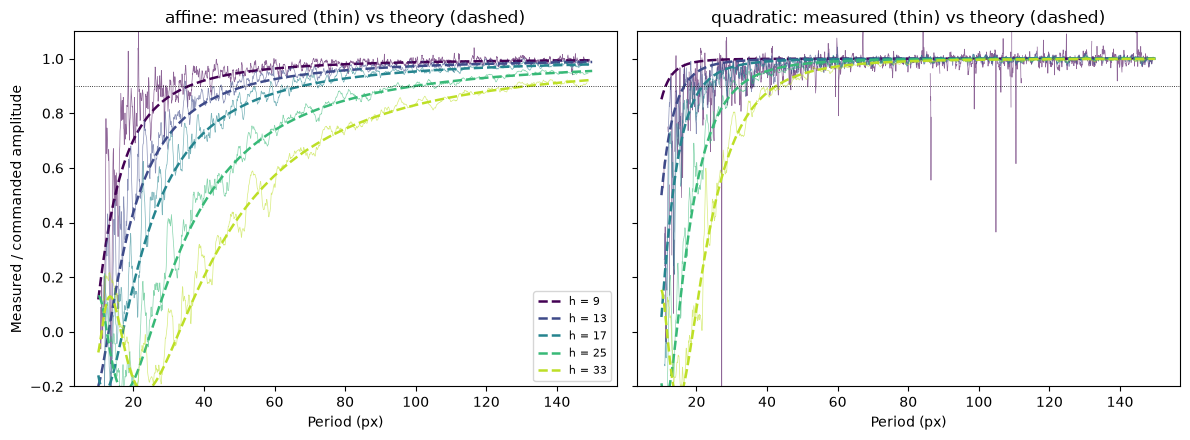

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colours = dict(zip(SUBSETS, plt.cm.viridis(np.linspace(0, 0.9, len(SUBSETS)))))
lam = np.linspace(STAR.period(0), STAR.period(W - 1), 2000)
for ax, shape in zip(axes, SHAPES):
    for subset in SUBSETS:
        c = cuts[(cuts["shape"] == shape) & (cuts.subset == subset)]
        ax.plot(c.period, c.ratio, color=colours[subset], lw=0.5, alpha=0.6)
        ax.plot(lam, attenuation_theory(subset, lam, ORDER[shape]), color=colours[subset],
                lw=1.8, ls="--", label=f"h = {subset}")
    ax.axhline(0.9, color="k", lw=0.6, ls=":")
    ax.set_title(f"{shape}: measured (thin) vs theory (dashed)")
    ax.set_xlabel("Period (px)")
    ax.set_ylim(-0.2, 1.1)
axes[0].set_ylabel("Measured / commanded amplitude")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / "star1_mei.pdf", dpi=300)


## Spatial resolution against subset (cf. Reu et al. Fig. 8)

Both theory lines have slope 1 on log axes; the quadratic line sits at about **0.32×** the affine one:
a quadratic subset resolves roughly three times finer features at the same size.

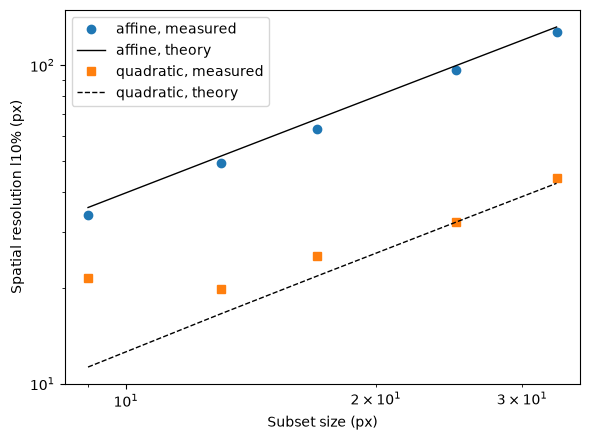

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
h = np.array(SUBSETS)
for shape, marker, style in (("affine", "o", "k-"), ("quadratic", "s", "k--")):
    s = summary[summary["shape"] == shape]
    ax.loglog(s.subset, s.l10_measured, marker, label=f"{shape}, measured")
    ax.loglog(h, [theoretical_resolution(x, ORDER[shape]) for x in h], style, lw=1, label=f"{shape}, theory")
ax.set_xlabel("Subset size (px)")
ax.set_ylabel("Spatial resolution l10% (px)")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "star1_mei_summary.pdf", dpi=300)


In [ ]:
out = RESULTS / "star1"
out.mkdir(parents=True, exist_ok=True)
summary.to_csv(out / "star1_resolution_vs_theory.csv", index=False)
cuts.to_csv(out / "star1_linecuts.csv", index=False)
print("wrote", out / "star1_resolution_vs_theory.csv")
print("wrote", out / "star1_linecuts.csv")
